Tutorial 2: Prior Passing
=========================

In the previous tutorial, we used non-linear search chaining to break the model-fitting procedure down into two
non-linear searches. This used an initial search to fit a simple lens model, whose results were used to tune and
initialize the priors of a more complex lens model that was fitted by the second search.

However, the results were passed between searches were passed manually. I explicitly wrote out every result as a prior
containing the values inferred in the first search. **PyAutoLens** has an API for passing priors in a more generalized
way, which is the topic of this tutorial.

In [1]:

%matplotlib inline
from pyprojroot import here
workspace_path = str(here())
%cd $workspace_path
print(f"Working Directory has been set to `{workspace_path}`")

import numpy as np
from pathlib import Path
import autolens as al
import autolens.plot as aplt
import autofit as af

/Users/rosador/Documents/AGEL/autolens_workspace
Working Directory has been set to `/Users/rosador/Documents/AGEL/autolens_workspace`
JAX mode enabled

***JAX ENABLED*** 
    
Using JAX for grad/jit and GPU/TPU acceleration. 
To disable JAX, set: config -> general -> jax -> use_jax = false
    


__Initial Setup__

we'll use the same strong lensing data as the previous tutorial, where:

 - The lens galaxy's light is an `Sersic`.
 - The lens galaxy's total mass distribution is an `Isothermal` and `ExternalShear`.
 - The source galaxy's light is an `Exponential`.
 
All the usual steps for setting up a model fit (masking, analysis, etc.) are included below.

2025-10-27 14:43:07,351 - jax._src.xla_bridge - INFO - Unable to initialize backend 'cuda': 
2025-10-27 14:43:07,351 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-10-27 14:43:07,352 - jax._src.xla_bridge - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/autolens/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
2025-10-27 14:43:07,645 - autoarray.dataset.imaging.dataset - INFO - Imaging data has been trimmed or padded for FFT convolution.
  - Original shape : (100, 100)
  - FFT shape    : (72, 72)
Padding ensures accurate PSF convolution in Fourier sp

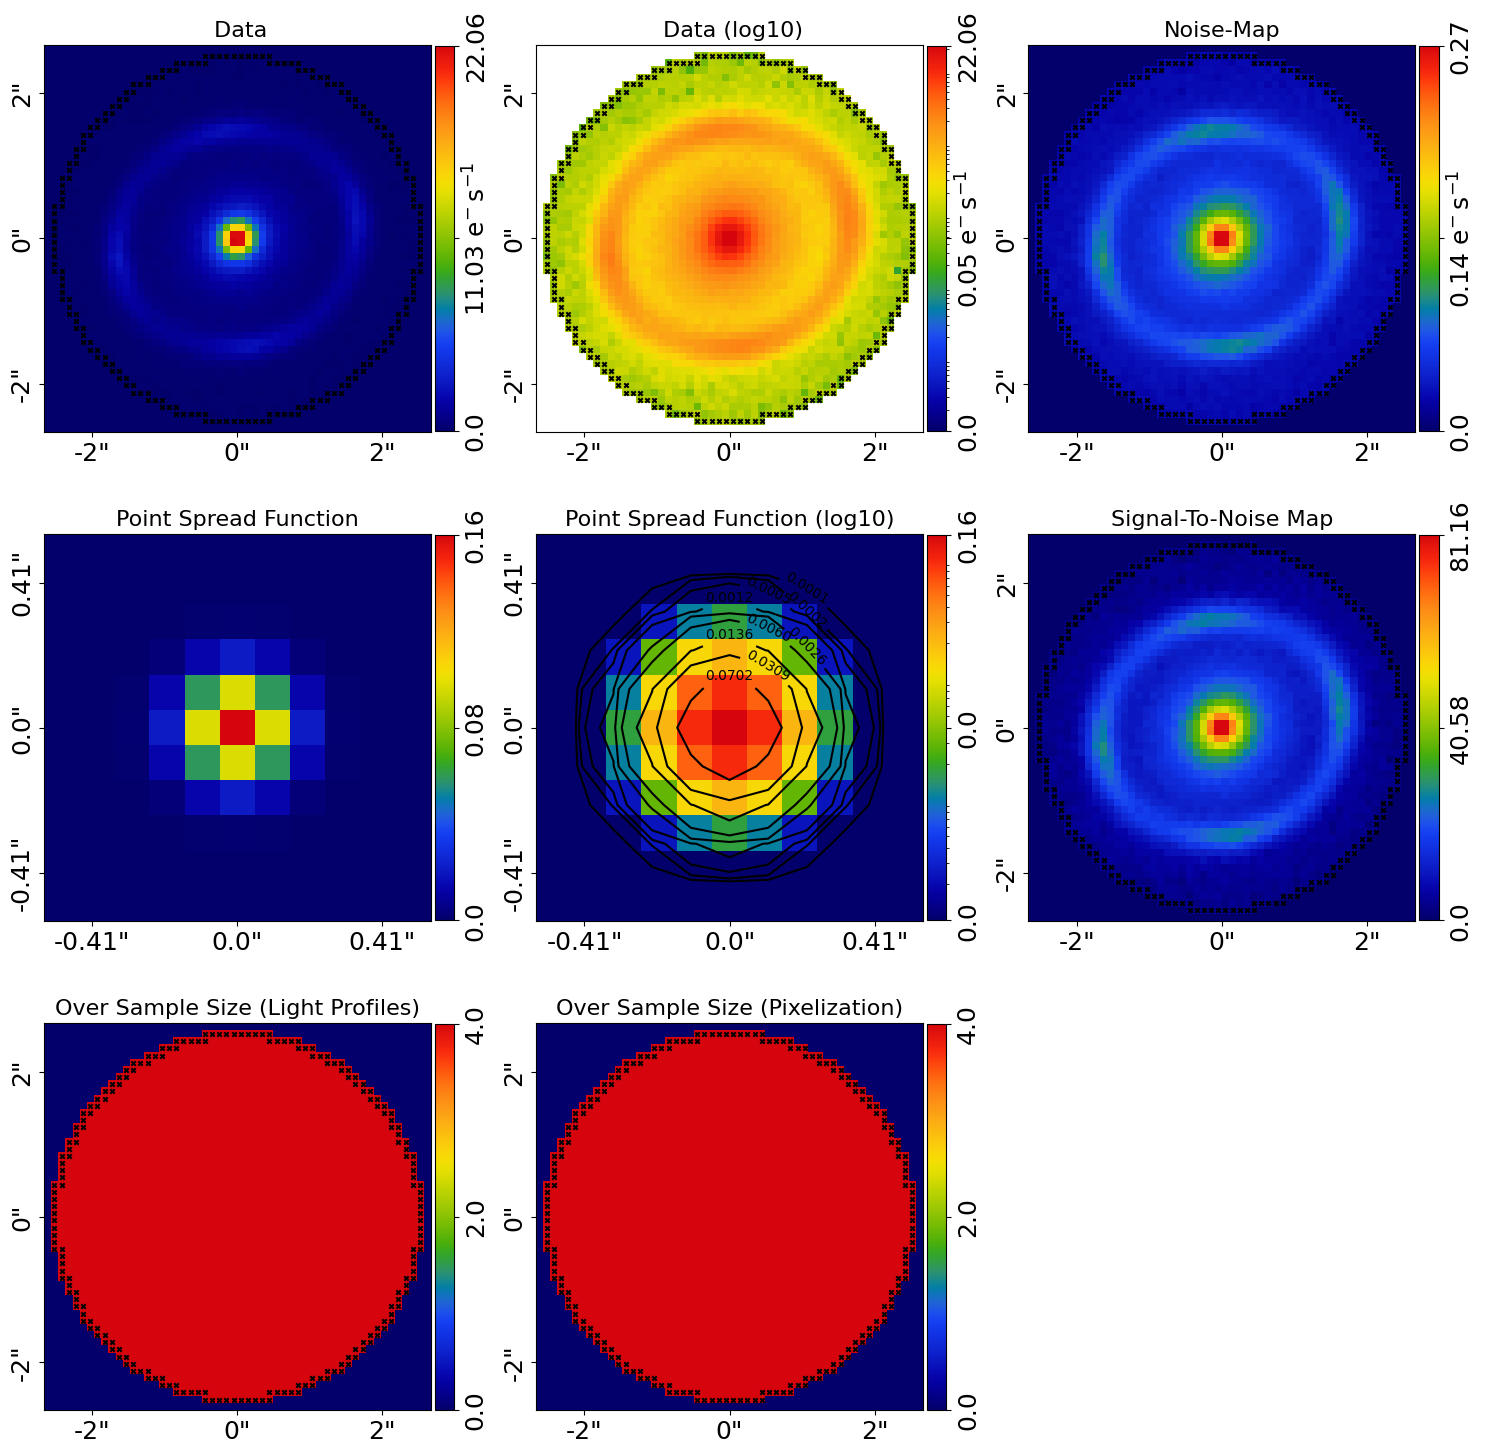

In [2]:
dataset_name = "lens_sersic"
dataset_path = Path("dataset") / "imaging" / dataset_name

dataset = al.Imaging.from_fits(
    data_path=dataset_path / "data.fits",
    noise_map_path=dataset_path / "noise_map.fits",
    psf_path=dataset_path / "psf.fits",
    pixel_scales=0.1,
)

mask_radius = 2.6

mask = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=mask_radius,
)

dataset = dataset.apply_mask(mask=mask)

dataset_plotter = aplt.ImagingPlotter(
    dataset=dataset, visuals_2d=aplt.Visuals2D(mask=mask)
)
dataset_plotter.subplot_dataset()

__Model__

We are going to use the same result of search 1 from the previous tutorial. Thus, we set up an identical model such 
that we instantly load the result from hard-disk.

In [3]:
bulge = af.Model(al.lp_linear.Sersic)
mass = af.Model(al.mp.Isothermal)

bulge.centre_0 = 0.0
bulge.centre_1 = 0.0
mass.centre_0 = 0.0
mass.centre_1 = 0.0

mass.ell_comps = bulge.ell_comps

bulge.sersic_index = 4.0

lens = af.Model(
    al.Galaxy, redshift=0.5, bulge=bulge, mass=mass, shear=al.mp.ExternalShear
)

source = af.Model(al.Galaxy, redshift=1.0, bulge=al.lp_linear.ExponentialCore)

model_1 = af.Collection(galaxies=af.Collection(lens=lens, source=source))

The `info` attribute shows the model in a readable format.

In [4]:
print(model_1.info)

Total Free Parameters = 11

model                                                                           Collection (N=11)
    galaxies                                                                    Collection (N=11)
        lens                                                                    Galaxy (N=6)
            bulge                                                               Sersic (N=3)
            mass                                                                Isothermal (N=3)
            shear                                                               ExternalShear (N=2)
        source                                                                  Galaxy (N=5)
            bulge                                                               ExponentialCore (N=5)

galaxies
    lens
        redshift                                                                0.5
        bulge - mass
            centre
                centre_0                               

__Search__

We also create the same search as the previous tutorial, using the same name to ensure we use the same results, and 
run it.

In [5]:
search_1 = af.Nautilus(
    path_prefix=Path("howtolens", "chapter_3"),
    name="tutorial_1_search_chaining_1",
    unique_tag=dataset_name,
    n_live=100,
)

analysis_1 = al.AnalysisImaging(dataset=dataset)

result_1 = search_1.fit(model=model_1, analysis=analysis_1)

2025-10-27 14:43:08,527 - autofit.non_linear.search.abstract_search - INFO - Starting non-linear search with 1 cores.
2025-10-27 14:43:08,601 - tutorial_1_search_chaining_1 - INFO - The output path of this fit is /Users/rosador/Documents/AGEL/autolens_workspace/output/howtolens/chapter_3/lens_sersic/tutorial_1_search_chaining_1/c6d863c553bf8d33a5bbf58f63293f56
2025-10-27 14:43:08,634 - tutorial_1_search_chaining_1 - INFO - Fit Already Completed: skipping non-linear search.
2025-10-27 14:43:08,709 - tutorial_1_search_chaining_1 - INFO - Removing search internal folder.
2025-10-27 14:43:08,709 - tutorial_1_search_chaining_1 - INFO - Removing all files except for .zip file
2025-10-27 14:43:08,825 - tutorial_1_search_chaining_1 - INFO - Search complete, returning result


__Result (Search 1)__

The results which are used for prior passing are summarised in the `info` attribute.

In [6]:
print(result_1.info)

Bayesian Evidence                                                               3741.82916488
Maximum Log Likelihood                                                          3812.85001598
Maximum Log Posterior                                                           3813.91433632

model                                                                           Collection (N=11)
    galaxies                                                                    Collection (N=11)
        lens                                                                    Galaxy (N=6)
            bulge                                                               Sersic (N=3)
            mass                                                                Isothermal (N=3)
            shear                                                               ExternalShear (N=2)
        source                                                                  Galaxy (N=5)
            bulge                            

__Prior Passing__

We are now going to use the prior passing API to pass these results, in a way which does not require us to manually 
write out the inferred parameter values of each component. The details of how prior passing is performed will be 
expanded upon at the end of the tutorial.

We start with the lens's bulge, which in the previous search was an `Sersic` with its centre fixed to (0.0, 0.0) 
and its `sersic_index` fixed to 4.0. The API for passing priors is shown below and there are two things worth noting:

 1) We pass the priors using the `model` attribute of the result. This informs **PyAutoLens** to pass the result as a
 model component that is to be fitted for in the next search, using priors that are initialized from the previous
 search's result. Note, if we pass as a `model` a parameter that was fixed in search 1 (e.g. the `sersic_index`) it 
 will be fixed to the same value in search 2.

 2) We do not pass the `centre` or `sersic_index` using `model`, because it would be fixed to the values that it was in 
 the first search. By omitting the centre, it uses the default priors on a lens galaxy, whereas we manually tell the 
 Sersic index to use a `TruncatedGaussianPrior` centred on 4.0. 

In [7]:
bulge = af.Model(al.lp_linear.Sersic)

bulge.ell_comps = result_1.model.galaxies.lens.bulge.ell_comps
bulge.effective_radius = result_1.model.galaxies.lens.bulge.effective_radius
bulge.sersic_index = af.TruncatedGaussianPrior(
    mean=4.0, sigma=2.0, lower_limit=0.0, upper_limit=5.0
)

For the mass, we again must account for how its centre was fixed to (0.0", 0.0") and therefore not pass the centre.
Passing the other parameters is the same as how we passed the bulge parameters, as is the shear.

In [8]:
mass = af.Model(al.mp.Isothermal)
mass.einstein_radius = result_1.model.galaxies.lens.mass.einstein_radius
mass.ell_comps = result_1.model.galaxies.lens.mass.ell_comps
shear = result_1.model.galaxies.lens.shear

For the source's bulge, we are passing the result of an `Exponential` to an `Sersic`. 

We can use a special prior passing method to do this, called `take_attributes`. This scans the `Exponential`
passed to the `take_attributes` method for all parameters which have the same name as the `Sersic` model,
and if their names are the same it passes their prior as a `model` (like we did above). Thus, it will locate all 6
parameters in common between the two profiles (centre_, ell_comps, intensity, effective_radius) and pass those,
leaving the `sersic_index`'s priors as the default values.

The `take_attributes` method is used in many examples of prior passing, when we pass a simpler parameterization of a
model to a more complex model. Another good example would be passing the result of a `IsothermalSph` to an
`Isothermal`.

In [9]:
source_bulge = af.Model(al.lp_linear.Sersic)
source_bulge.take_attributes(result_1.model.galaxies.source.bulge)

We now compose the model with these components that have had their priors customized. 

In [10]:
lens = af.Model(al.Galaxy, redshift=0.5, bulge=bulge, mass=mass, shear=shear)

source = af.Model(al.Galaxy, redshift=1.0, bulge=source_bulge)

model_2 = af.Collection(galaxies=af.Collection(lens=lens, source=source))

The `info` attribute shows the model, including how all priors are updated via prior passing.

In [11]:
print(model_2.info)

Total Free Parameters = 17

model                                                                           Collection (N=17)
    galaxies                                                                    Collection (N=17)
        lens                                                                    Galaxy (N=11)
            mass                                                                Isothermal (N=5)
            shear                                                               ExternalShear (N=2)
        source                                                                  Galaxy (N=6)
        lens - source
            bulge                                                               Sersic (N=6)

galaxies
    lens
        redshift                                                                0.5
        bulge
            centre
                centre_0                                                        GaussianPrior [18], mean = 0.0, sigma = 0.3
                c

__Search__

Lets setup and run the search. I have given it a different name to the previous tutorial so we can compare the priors
that were passed.

In [12]:
search_2 = af.Nautilus(
    path_prefix=Path("howtolens", "chapter_3"),
    name="tutorial_2_search_chaining_2",
    unique_tag=dataset_name,
    n_live=100,
)

analysis_2 = al.AnalysisImaging(dataset=dataset)

print(
    "The non-linear search has begun running - checkout the workspace/output/5_chaining_searches"
    " folder for live output of the results, images and lens model."
    " This Jupyter notebook cell with progress once search has completed - this could take some time!"
)

result_2 = search_2.fit(model=model_2, analysis=analysis_2)

print("Search has finished run - you may now continue the notebook.")

The non-linear search has begun running - checkout the workspace/output/5_chaining_searches folder for live output of the results, images and lens model. This Jupyter notebook cell with progress once search has completed - this could take some time!
2025-10-27 14:43:50,794 - autofit.non_linear.search.abstract_search - INFO - Starting non-linear search with 1 cores.
2025-10-27 14:43:50,832 - tutorial_2_search_chaining_2 - INFO - The output path of this fit is /Users/rosador/Documents/AGEL/autolens_workspace/output/howtolens/chapter_3/lens_sersic/tutorial_2_search_chaining_2/efa2f3be1883d2e95d9e4723032738db
2025-10-27 14:43:50,832 - tutorial_2_search_chaining_2 - INFO - Outputting pre-fit files (e.g. model.info, visualization).
2025-10-27 14:43:51,353 - tutorial_2_search_chaining_2 - INFO - Starting new Nautilus non-linear search (no previous samples found).
2025-10-27 14:43:51,353 - autofit.non_linear.fitness - INFO - JAX: Applying vmap and jit to likelihood function -- may take a few s

<Figure size 6800x6800 with 0 Axes>

__Result__

We can again inspect the results via the `info` attribute.

In [13]:
print(result_2.info)

Bayesian Evidence                                                               3718.59607587
Maximum Log Likelihood                                                          3818.39541037
Maximum Log Posterior                                                           3818.25172652

model                                                                           Collection (N=17)
    galaxies                                                                    Collection (N=17)
        lens                                                                    Galaxy (N=11)
            mass                                                                Isothermal (N=5)
            shear                                                               ExternalShear (N=2)
        source                                                                  Galaxy (N=6)
        lens - source
            bulge                                                               Sersic (N=6)

Maximum Log Likelihoo

And a plot of the image shows we get a good model again!

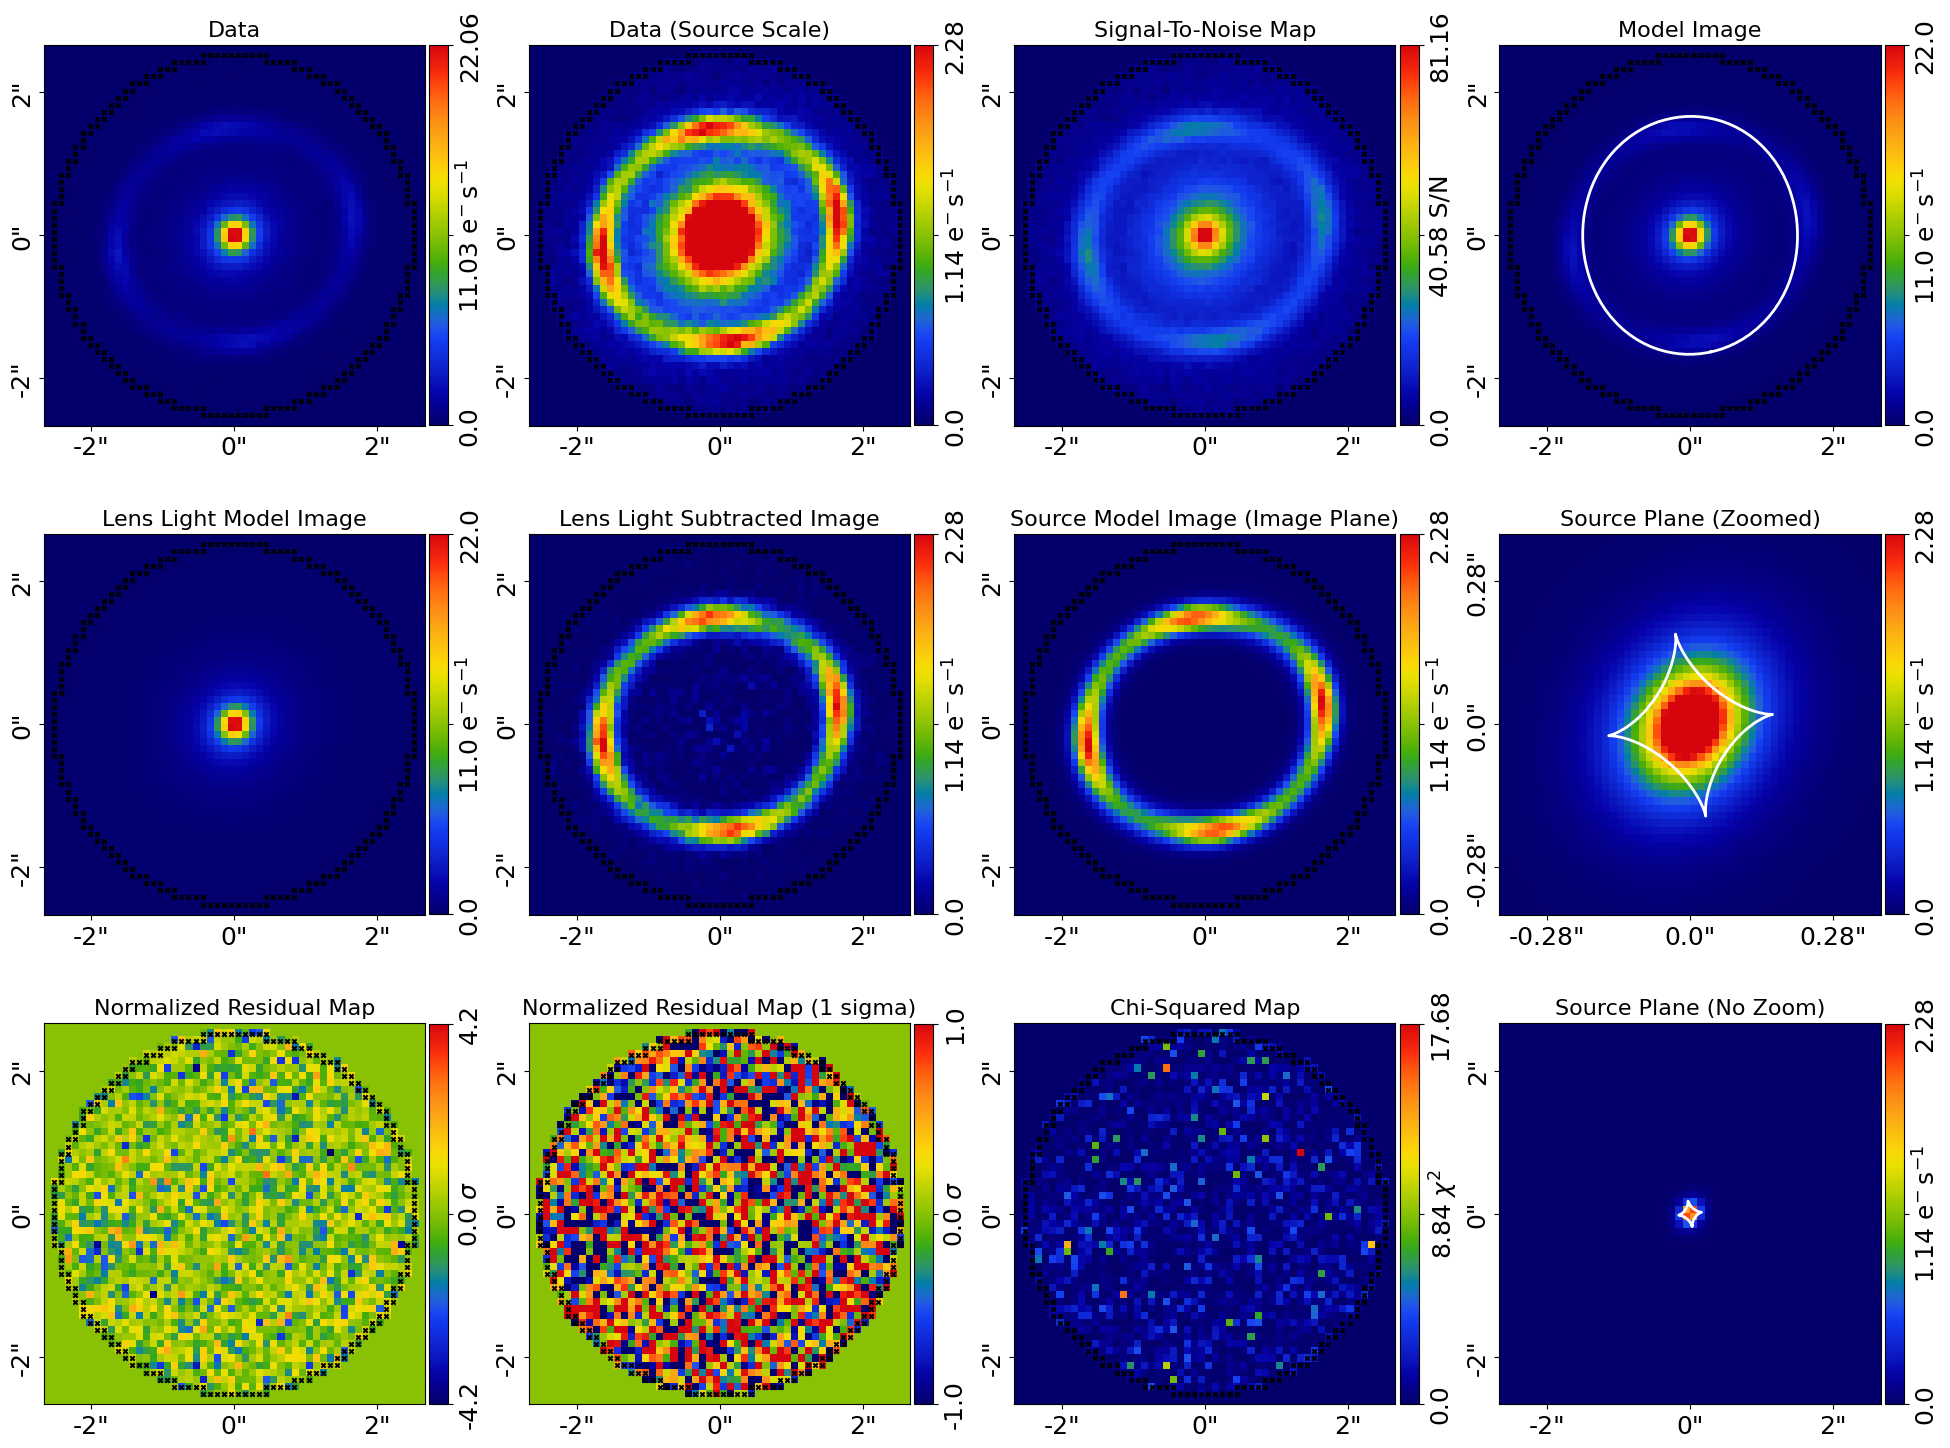

In [14]:
fit_plotter = aplt.FitImagingPlotter(fit=result_2.max_log_likelihood_fit)
fit_plotter.subplot_fit()

__Wrap Up__

We will expand on the prior passing API in the following tutorials. The main thing to note is that we can pass 
entire profiles or galaxies using prior passing, if their model does not change (which for the bulge, mass and 
source_bulge above, was not true). The API to pass a whole profile or galaxy is as follows:
 
 bulge = result_1.model.galaxies.lens.bulge
 lens = result_1.model.galaxies.lens
 source = result_1.model.galaxies.source
 
We can also pass priors using an `instance` instead of a `model`. When an `instance` is used, the maximum likelihood
parameter values are passed as fixed values that are therefore not fitted for nby the non-linear search (reducing its
dimensionality). We will use this in the next tutorial to fit the lens light, fix it to the best-fit model in a second
search, and then go on to fit it as a model in the final search.
 
Lets now think about how priors are passed. Checkout the `model.info` file of the second search of this tutorial. The 
parameters do not use the default priors we saw in search 1 (which are typically broad UniformPriors). Instead, 
they use GaussianPrior`s where:

 - The mean values are the median PDF results of every parameter in search 1.
 - The sigma values are specified in the `width_modifier` field of the profile's entry in the `priors.yaml' config 
   file (we will discuss why this is used in a moment).

Like the manual `GaussianPrior`'s that were used in tutorial 1, the prior passing API sets up the prior on each 
parameter with a `GaussianPrior` centred on the high likelihood regions of parameter space!

__Detailed Explanation Of Prior Passing__

To end, I provide a detailed overview of how prior passing works and illustrate tools that can be used to customize
its behaviour. It is up to you whether you want read this, or go ahead to the next tutorial!

Lets say I chain two parameters as follows:
 
 `mass.einstein_radius = result_1.model.galaxies.lens.mass.einstein_radius`

By invoking the `model` attribute, the prior is passed following 3 rules:

 1) The new parameter, in this case the einstein radius, uses a `GaussianPrior`.This is ideal, as the 1D pdf results 
 we compute at the end of a search are easily summarised as a Gaussian.

 2) The mean of the `GaussianPrior` is the median PDF value of the parameter estimated in search 1.
    
 This ensures that the initial sampling of the new search's non-linear starts by searching the region of non-linear 
 parameter space that correspond to highest log likelihood solutions in the previous search. Our priors therefore 
 correspond to the `correct` regions of parameter space.

 3) The sigma of the Gaussian uses the value specified for the profile in the `config/priors/*.yaml` config file's 
 `width_modifer` field (check these files out now).

The idea here is simple. We want a value of sigma that gives a `GaussianPrior` wide enough to search a broad 
region of parameter space, so that the lens model can change if a better solution is nearby. However, we want it 
to be narrow enough that we don't search too much of parameter space, as this will be slow or risk leading us 
into an incorrect solution! 

The `width_modifier` values in the priors config file have been chosen based on our experience as being a good
balance broadly sampling parameter space but not being so narrow important solutions are missed.
       
There are two ways a value is specified using the priors/width file:

 1) Absolute: In this case, the error assumed on the parameter is the value given in the config file. 
 For example, if for the width on centre_0 of a light profile, the width modifier reads "Absolute" with a value 
 0.05. This means if the error on the parameter centre_0 was less than 0.05 in the previous search, the sigma of 
 its `GaussianPrior` in this search will be 0.05.
    
 2) Relative: In this case, the error assumed on the parameter is the % of the value of the estimated value given in 
 the config file. For example, if the intensity estimated in the previous search was 2.0, and the relative error in 
 the config file reads "Relative" with a value 0.5, then the sigma of the `GaussianPrior` will be 50% of this 
 value, i.e. sigma = 0.5 * 2.0 = 1.0.

We use absolute and relative values for different parameters, depending on their properties. For example, using the 
relative value of a parameter like the `Profile` centre makes no sense. If our lens galaxy is centred at (0.0, 0.0), 
the relative error will always be tiny and thus poorly defined. Therefore, the default configs in **PyAutoLens** use 
absolute errors on the centre.

However, there are parameters where using an absolute value does not make sense. Intensity is a good example of this. 
The intensity of an image depends on its units, S/N, galaxy brightness, etc. There is no single absolute value that 
one can use to generically chain the intensity of any two proflies. Thus, it makes more sense to chain them using 
the relative value from a previous search.

We can customize how priors are passed from the results of a search and non-linear search by editing the
 `prior_passer` settings in the `general.yaml` config file.

__EXAMPLE__

Lets go through an example using a real parameter. Lets say in search 1 we fit the lens galaxy's light with an 
elliptical Sersic profile, and we estimate that its sersic index is equal to 4.0.
 
To pass this as a prior to search 2 we write:

 lens.bulge.sersic_index = result_1.model.lens.bulge.sersic_index

The prior on the lens galaxy's bulge sersic index in search 2 would thus be a `GaussianPrior` with mean=4.0. 

The value of the Sersic index `width_modifier` in the priors config file sets sigma. The prior config file specifies 
that we use an "Absolute" value of 0.8 to chain this prior. Thus, the `GaussianPrior` in search 2 would have a 
mean=4.0 and sigma=0.8.

If the prior config file had specified that we use an relative value of 0.8, the GaussianPrior in search 2 would have a 
mean=4.0 and sigma = 4.0 * 0.8 = 3.2.

And with that, we're done. Chaining priors is a bit of an art form, but one that works really well. 